In [2]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse
from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning
import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)




### Preparing the sample (mostra de RedClumps)
#### The GALAH DR3 RC sample
The GALAH DR3 red-clump sample is a selection of RC stars from the GALAH DR3 catalogue. I have put together the possibly interesting portions of the catalogs and cut a sample of red clump (RC) stars using topcat: (teff > 4500 && teff < 5100 && logg > 2.3 && logg < 2.55 && is_redclump_bstep > 0.5). This sample contains 37,417 stars.

In [3]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()   

### Prepare the input arrays for XD

In [4]:
galah_rc.get_ndimspace(feh=True, norm="stdev")
N = 400

X = galah_rc.X            #(10941, 24)
Xerr = galah_rc.Xerr1         #(10941, 24)
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2    #(10941, 24, 24)
#cal calcular una matriu W???  no pq errors d'un element no influeixen en errors d'un altre, en una mateixa estrella

In [5]:
@
def compute_XD(n_clusters=5, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_clusters, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov) 
    return clf

clf = compute_XD(5)

#clf = XDGMM(n_components=10, max_iter=200)

#clf.fit(X, Xerr1)
#sample = clf.sample(N)


# plot noisy distribution
# plot_distribution('Extreme Deconvolution Resampling', sample[:, 0], sample[:, 1])

C:\Users\aleix\anaconda3\lib\site-packages\sklearn\mixture\_base.py:265: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn('Initialization %d did not converge. '


1: log(L) = -29380
    (7.1 sec)
2: log(L) = -29374
    (7.1 sec)
3: log(L) = -29368
    (7 sec)
4: log(L) = -29363
    (7.7 sec)
5: log(L) = -29359
    (7 sec)
6: log(L) = -29356
    (7.1 sec)
7: log(L) = -29352
    (6.9 sec)
8: log(L) = -29349
    (7.1 sec)
9: log(L) = -29345
    (7.1 sec)
10: log(L) = -29341
    (7.2 sec)
11: log(L) = -29337
    (7.1 sec)
12: log(L) = -29332
    (7.3 sec)
13: log(L) = -29328
    (7.2 sec)
14: log(L) = -29324
    (7 sec)
15: log(L) = -29321
    (7 sec)
16: log(L) = -29318
    (7.1 sec)
17: log(L) = -29315
    (7 sec)
18: log(L) = -29313
    (7 sec)
19: log(L) = -29311
    (7.2 sec)
20: log(L) = -29309
    (7.1 sec)
21: log(L) = -29308
    (8.3 sec)
22: log(L) = -29306
    (7.5 sec)
23: log(L) = -29305
    (7.5 sec)
24: log(L) = -29304
    (12 sec)
25: log(L) = -29302
    (8.6 sec)
26: log(L) = -29301
    (9.2 sec)
27: log(L) = -29300
    (9.2 sec)
28: log(L) = -29299
    (7.2 sec)
29: log(L) = -29298
    (6.8 sec)
30: log(L) = -29297
    (7.3 sec)
31

In [6]:
# Fit and sample from the underlying distribution
np.random.seed(42)
X_sample = clf.sample(X.shape[0])

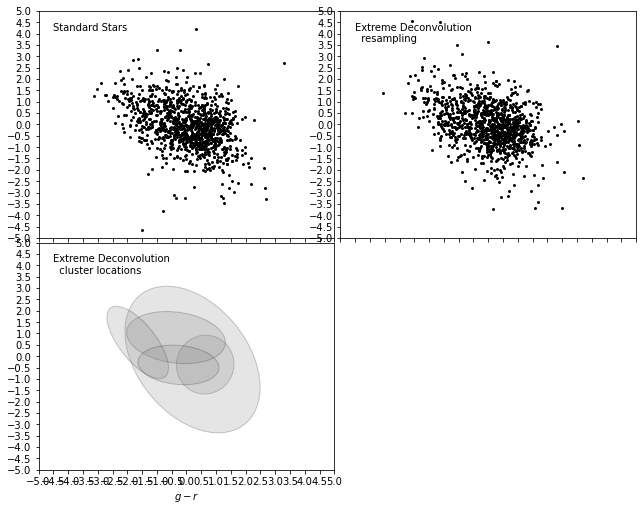

In [8]:
# plot the results
fig = plt.figure(figsize=(10, 7.5))
fig.subplots_adjust(left=0.12, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity
#noisy
ax1 = fig.add_subplot(221)
ax1.scatter(X[::10, 0], X[::10, 1], s=9, lw=0, c='k')   
#XDeconvulotioned
ax2 = fig.add_subplot(222)
ax2.scatter(X_sample[::10, 0], X_sample[::10, 1], s=9, lw=0, c='k')
#elipses
ax3 = fig.add_subplot(223)
for i in range(clf.n_components):
    draw_ellipse(clf.mu[i, 0:2], clf.V[i, 0:2, 0:2], scales=[2],
                 ec='k', fc='gray', alpha=0.2, ax=ax3)

titles = ["Standard Stars","Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]
ax = [ax1, ax2, ax3]

for i in range(3):
    ax[i].set_xlim(-5, 5)
    ax[i].set_ylim(-5, 5)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$g-r$')

correr per 24 dimensions guardant a pickle (així no cal esperar cada vegada), plotejar primer unes 5.
